First Five Rows
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 

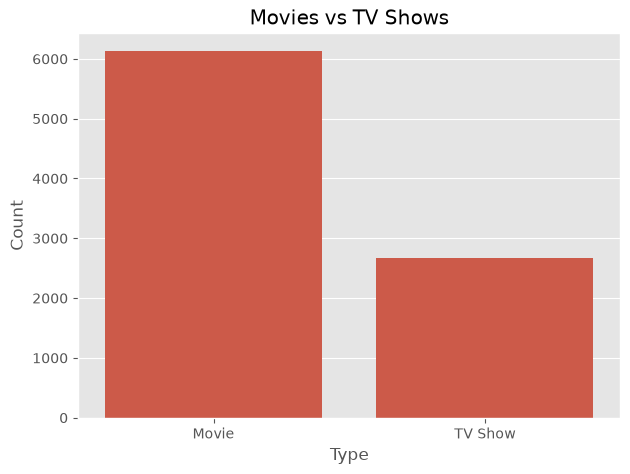

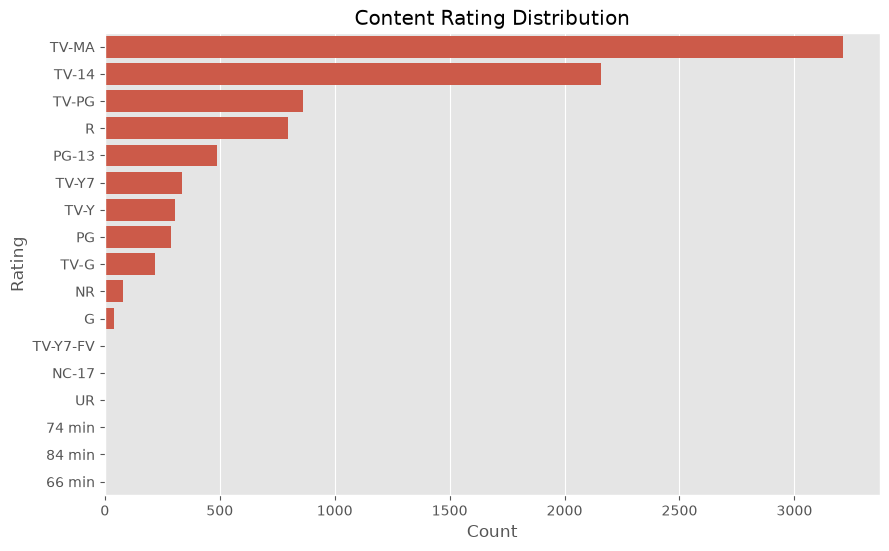

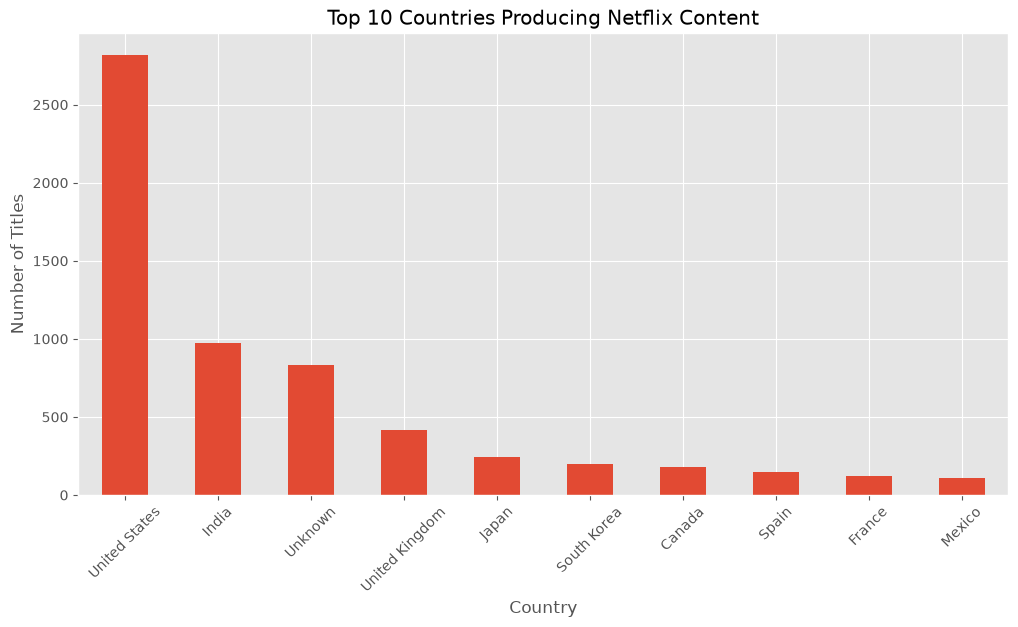

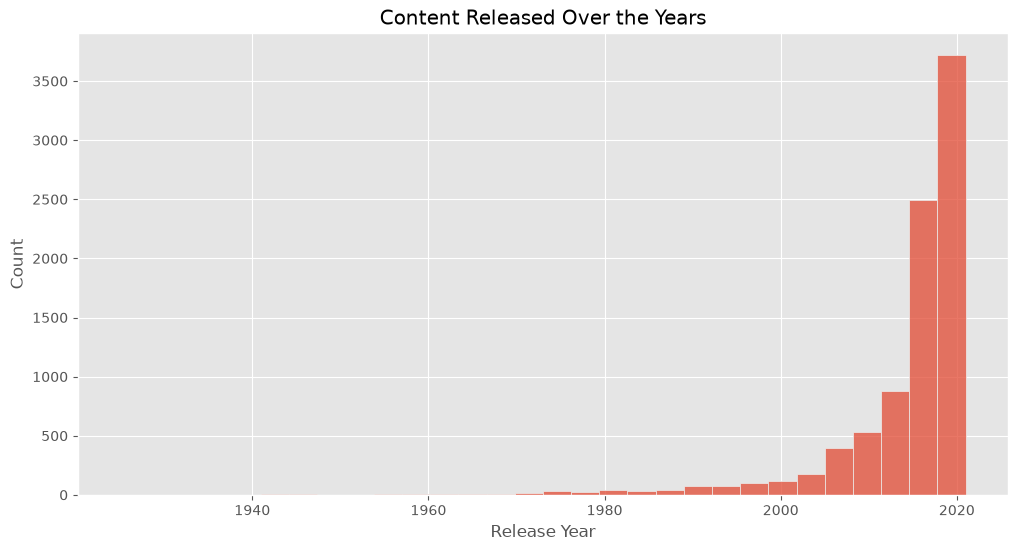

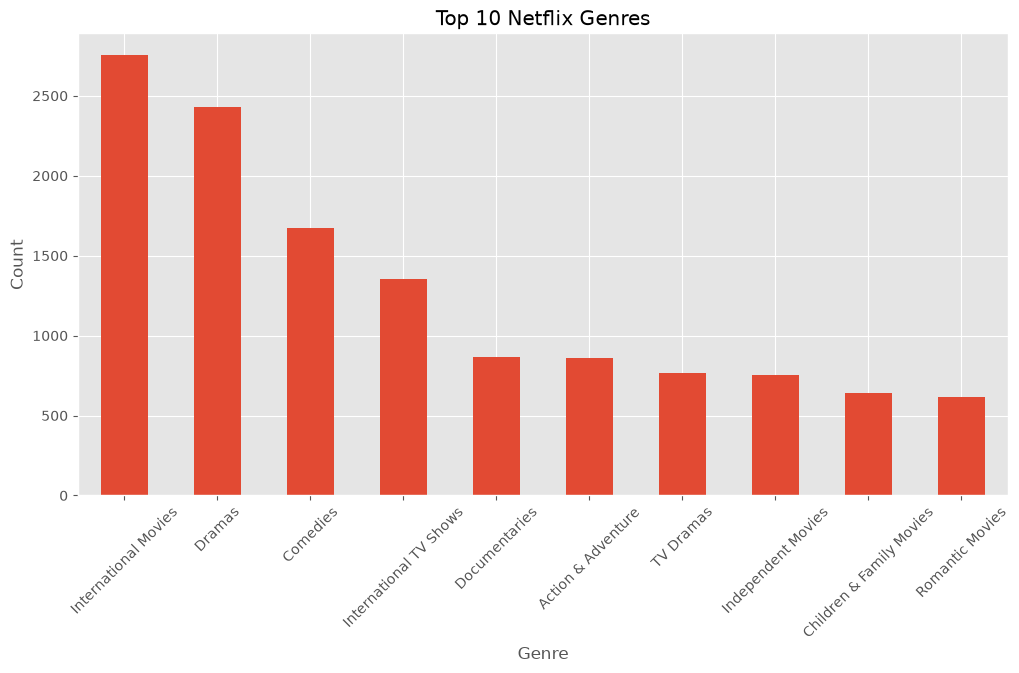

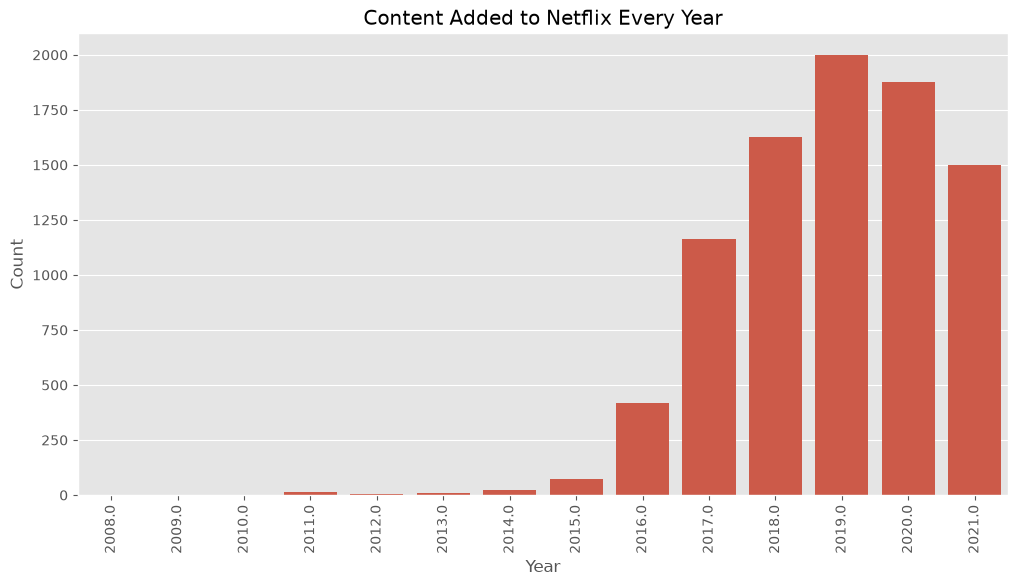

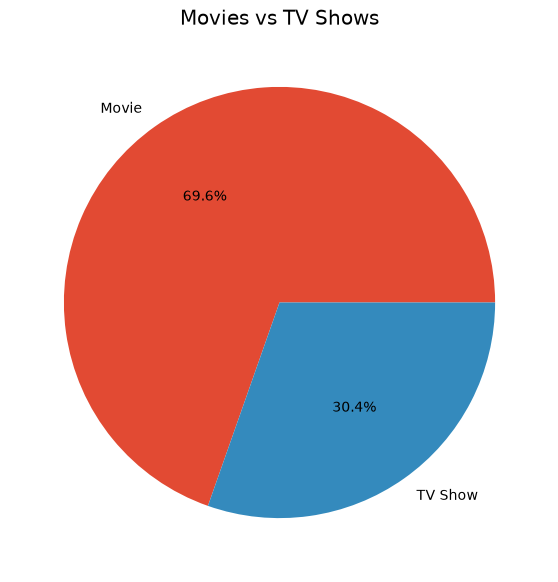

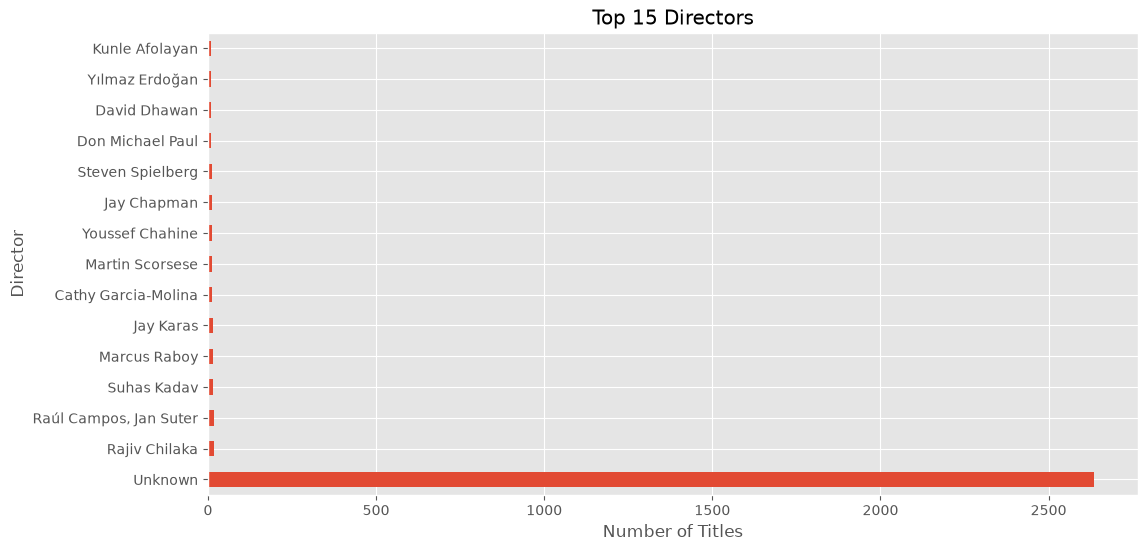

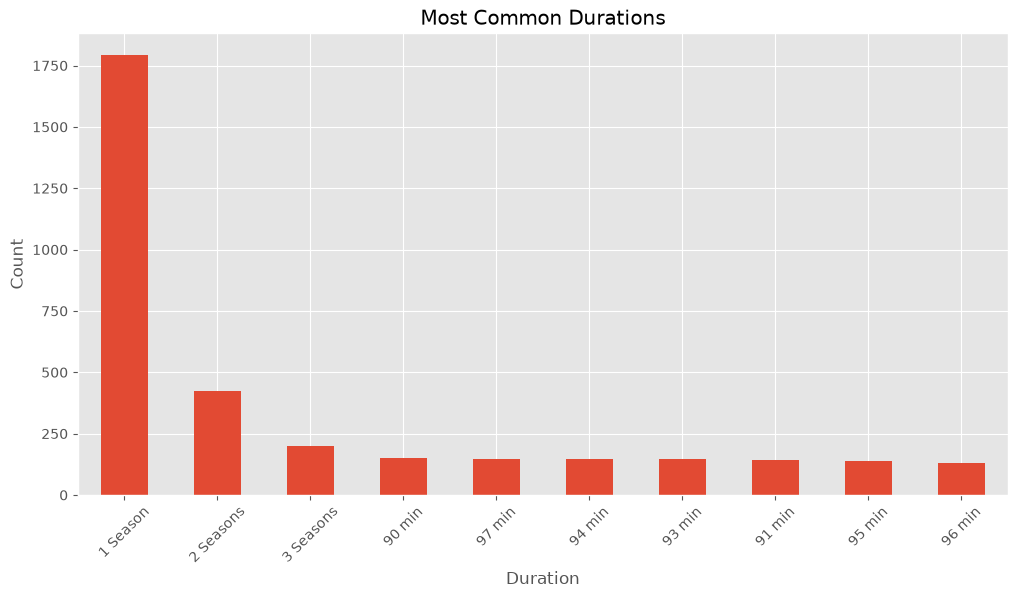

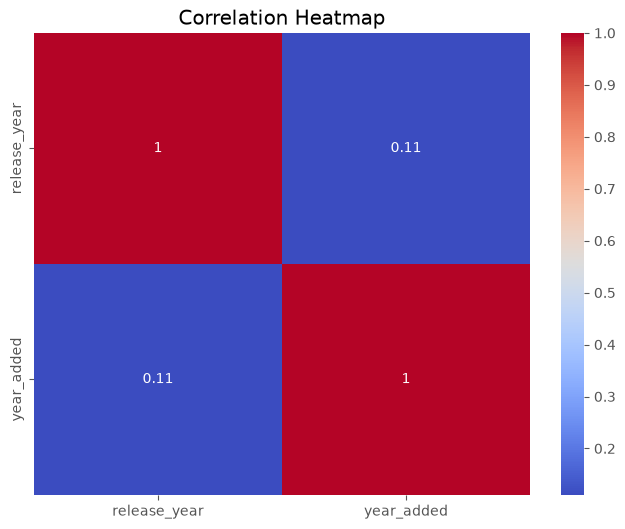

In [ ]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set graph style
plt.style.use("ggplot")


# Load Dataset


df = pd.read_csv("netflix_titles.csv")


# Display Dataset

print("First Five Rows")
print(df.head())

print("\n")

print("Dataset Information")
print(df.info())

print("\n")

print("Statistical Summary")
print(df.describe(include="all"))

print("\n")

print("Dataset Shape")
print(df.shape)

print("\n")

print("Column Names")
print(df.columns.tolist())


# Check Missing Values


print("\nMissing Values")
print(df.isnull().sum())

# Handle Missing Values

df["director"] = df["director"].fillna("Unknown")

df["cast"] = df["cast"].fillna("Unknown")

df["country"] = df["country"].fillna("Unknown")

df["rating"] = df["rating"].fillna(df["rating"].mode()[0])

df["date_added"] = df["date_added"].fillna("Unknown")

# Remove Duplicate Rows

print("\nDuplicate Rows :", df.duplicated().sum())

df.drop_duplicates(inplace=True)

# Convert Date Column

df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

# Data Types After Cleaning

print("\nUpdated Dataset Information")

print(df.info())

# Exploratory Data Analysis

plt.figure(figsize=(7,5))

sns.countplot(x="type", data=df)

plt.title("Movies vs TV Shows")

plt.xlabel("Type")

plt.ylabel("Count")

plt.show()


# Content Ratings

plt.figure(figsize=(10,6))

sns.countplot(
    y="rating",
    data=df,
    order=df["rating"].value_counts().index
)

plt.title("Content Rating Distribution")

plt.xlabel("Count")

plt.ylabel("Rating")

plt.show()


# Top 10 Countries

plt.figure(figsize=(12,6))

df["country"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Countries Producing Netflix Content")

plt.xlabel("Country")

plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()

# Release Year Distribution

plt.figure(figsize=(12,6))

sns.histplot(df["release_year"], bins=30)

plt.title("Content Released Over the Years")

plt.xlabel("Release Year")

plt.ylabel("Count")

plt.show()

# Top Genres

genres = df["listed_in"].str.split(", ").explode()

plt.figure(figsize=(12,6))

genres.value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Netflix Genres")

plt.xlabel("Genre")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

# Content Added to Netflix by Year

df["year_added"] = df["date_added"].dt.year

plt.figure(figsize=(12,6))

sns.countplot(
    x="year_added",
    data=df,
    order=sorted(df["year_added"].dropna().unique())
)

plt.xticks(rotation=90)

plt.title("Content Added to Netflix Every Year")

plt.xlabel("Year")

plt.ylabel("Count")

plt.show()

# Pie Chart

plt.figure(figsize=(7,7))

df["type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Movies vs TV Shows")

plt.ylabel("")

plt.show()

# Top 15 Directors

plt.figure(figsize=(12,6))

df["director"].value_counts().head(15).plot(kind="barh")

plt.title("Top 15 Directors")

plt.xlabel("Number of Titles")

plt.ylabel("Director")

plt.show()

# Most Common Durations

plt.figure(figsize=(12,6))

df["duration"].value_counts().head(10).plot(kind="bar")

plt.title("Most Common Durations")

plt.xlabel("Duration")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

# Correlation Heatmap

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

